In [9]:
import pandas as pd
import numpy as np

df=pd.read_csv('data/car_price.csv')
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [10]:
df.dtypes

car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

In [11]:
df.nunique()

car_ID              205
symboling             6
CarName             147
fueltype              2
aspiration            2
doornumber            2
carbody               5
drivewheel            3
enginelocation        2
wheelbase            53
carlength            75
carwidth             44
carheight            49
curbweight          171
enginetype            7
cylindernumber        7
enginesize           44
fuelsystem            8
boreratio            38
stroke               37
compressionratio     32
horsepower           59
peakrpm              23
citympg              29
highwaympg           30
price               189
dtype: int64

In [12]:
df['brand']=df['CarName'].str.split().str[0]
df.drop(columns=['CarName'], axis=1, inplace=True)
df.nunique()

car_ID              205
symboling             6
fueltype              2
aspiration            2
doornumber            2
carbody               5
drivewheel            3
enginelocation        2
wheelbase            53
carlength            75
carwidth             44
carheight            49
curbweight          171
enginetype            7
cylindernumber        7
enginesize           44
fuelsystem            8
boreratio            38
stroke               37
compressionratio     32
horsepower           59
peakrpm              23
citympg              29
highwaympg           30
price               189
brand                28
dtype: int64

In [13]:
df.isnull().sum()

car_ID              0
symboling           0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
brand               0
dtype: int64

In [31]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
ohe=OneHotEncoder()
obj_cols=df.select_dtypes(include='object').columns
num_cols=['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']
other_cols=['price', 'symboling']
df[num_cols]=scaler.fit_transform(df[num_cols]) 
df_ohe=pd.DataFrame(ohe.fit_transform(df[obj_cols]).toarray(), columns=ohe.get_feature_names_out())
df_final=pd.concat([df[num_cols], df_ohe, df[other_cols]], axis=1)

In [32]:
df_final

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,...,brand_saab,brand_subaru,brand_toyota,brand_toyouta,brand_vokswagen,brand_volkswagen,brand_volvo,brand_vw,price,symboling
0,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,0.074449,0.519071,-1.839377,-0.288349,0.174483,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13495.0,3
1,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,0.074449,0.519071,-1.839377,-0.288349,0.174483,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16500.0,3
2,-0.708596,-0.231513,-0.190566,-0.543527,0.514882,0.604046,-2.404880,0.685946,-0.288349,1.264536,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16500.0,1
3,0.173698,0.207256,0.136542,0.235942,-0.420797,-0.431076,-0.517266,0.462183,-0.035973,-0.053668,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13950.0,2
4,0.107110,0.207256,0.230001,0.235942,0.516807,0.218885,-0.517266,0.462183,-0.540725,0.275883,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17450.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,1.721873,1.198549,1.398245,0.728239,0.763241,0.339248,1.666445,-0.336970,-0.162161,0.250533,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16845.0,-1
201,1.721873,1.198549,1.351515,0.728239,0.949992,0.339248,1.666445,-0.336970,-0.364062,1.416637,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,19045.0,-1
202,1.721873,1.198549,1.398245,0.728239,0.878757,1.109571,0.926204,-1.232021,-0.338824,0.757535,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,21485.0,-1
203,1.721873,1.198549,1.398245,0.728239,1.273437,0.435538,-1.183483,0.462183,3.244916,0.047732,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,22470.0,-1


In [46]:
from sklearn.model_selection import train_test_split
x=df_final.drop(columns='price', axis=1).values
y=df_final['price'].values



In [47]:
y

array([13495.   , 16500.   , 16500.   , 13950.   , 17450.   , 15250.   ,
       17710.   , 18920.   , 23875.   , 17859.167, 16430.   , 16925.   ,
       20970.   , 21105.   , 24565.   , 30760.   , 41315.   , 36880.   ,
        5151.   ,  6295.   ,  6575.   ,  5572.   ,  6377.   ,  7957.   ,
        6229.   ,  6692.   ,  7609.   ,  8558.   ,  8921.   , 12964.   ,
        6479.   ,  6855.   ,  5399.   ,  6529.   ,  7129.   ,  7295.   ,
        7295.   ,  7895.   ,  9095.   ,  8845.   , 10295.   , 12945.   ,
       10345.   ,  6785.   ,  8916.5  ,  8916.5  , 11048.   , 32250.   ,
       35550.   , 36000.   ,  5195.   ,  6095.   ,  6795.   ,  6695.   ,
        7395.   , 10945.   , 11845.   , 13645.   , 15645.   ,  8845.   ,
        8495.   , 10595.   , 10245.   , 10795.   , 11245.   , 18280.   ,
       18344.   , 25552.   , 28248.   , 28176.   , 31600.   , 34184.   ,
       35056.   , 40960.   , 45400.   , 16503.   ,  5389.   ,  6189.   ,
        6669.   ,  7689.   ,  9959.   ,  8499.   , 

In [49]:
from sklearn.metrics import mean_squared_error
class LinearRegressionGD:
    def __init__ (self, n_features, lr=0.01):
        self.lr=lr
        self.W=np.zeros(n_features)
        self.b=0.0
        self.loss_history=[]
    def predict(self, x):
        return np.dot(x, self.W)+self.b
    def mse(self, y, y_pred):
        return mean_squared_error(y, y_pred)
    def fit(self, x, y, epochs=1000):
        n=y.shape[0]
        for i in range(epochs):
            y_pred=self.predict(x)
            
            #cost
            loss=self.mse(y, y_pred)
            self.loss_history.append(loss)

            #gradients
            dW=(-2/n)*np.dot(x.T, y-y_pred)
            db=(-2/n)*np.sum(y-y_pred)

            #update weights
            self.W=self.W-self.lr*dW
            self.b=self.b-self.lr*db


In [44]:
x.T.shape

(80, 205)

In [48]:
x.shape
y.shape

(205,)

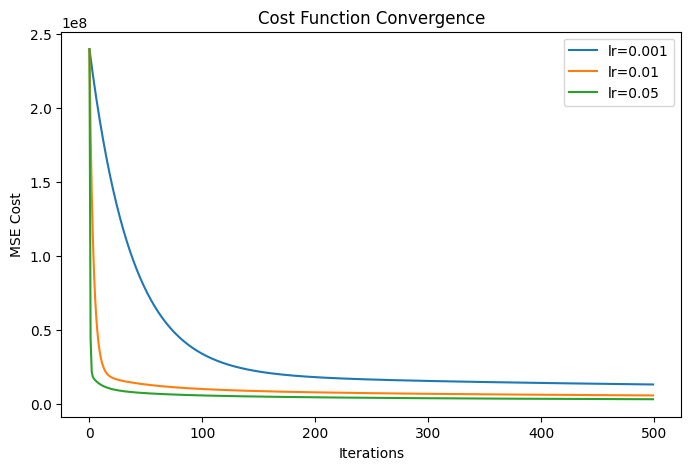

In [50]:
#task4
import matplotlib.pyplot as plt
learning_rates=[0.001, 0.01, 0.05]

models={}
for lr in learning_rates:
    model=LinearRegressionGD(n_features=x.shape[1], lr=lr)
    model.fit(x, y, epochs=500)
    models[lr]=model
plt.figure(figsize=(8,5))
for lr, model in models.items():
    plt.plot(model.loss_history, label=f"lr={lr}")
plt.xlabel('Iterations')
plt.ylabel('MSE Cost')
plt.title("Cost Function Convergence")
plt.legend()
plt.show()


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)
def mse_score(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)
def r2_score_func(y_true, y_pred):
    return r2_score(y_true, y_pred)
model=LinearRegressionGD(n_features=x.shape[1], lr=0.01)
model.fit(x_train, y_train, epochs=1000)

train_preds=model.predict(x_train)
test_preds=model.predict(x_test)

print('Train MSE:', mse_score(y_train, train_preds))
print('Test MSE:', mse_score(y_test, test_preds))
print('Train R2 Score:', r2_score_func(y_train, train_preds))
print('Test R2 Score:', r2_score_func(y_test, test_preds))



Train MSE: 3807100.651867754
Test MSE: 10024188.994545417
Train R2 Score: 0.9361629995530132
Test R2 Score: 0.8730215552381567


In [54]:
for i in range(5):
    print(f'Actual: {y_test[i]} | Predicted: {test_preds[i]}')

Actual: 30760.0 | Predicted: 29671.315037443575
Actual: 17859.167 | Predicted: 17101.378305513605
Actual: 9549.0 | Predicted: 9576.086544088073
Actual: 11850.0 | Predicted: 13512.63031954011
Actual: 28248.0 | Predicted: 28516.918085984988
